<a href="https://colab.research.google.com/github/floresarthurjr/ecommerce-recommendation-engine/blob/main/notebooks/Arthur_C_Flores_Jr__Pillar_5_Capstone_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Step 1: Problem Understanding & Framing**

*   Frame the business and data science problem clearly
*   Define whether it's a classification, regression, recommendation, anomaly detection, or clustering task
* Specify success metrics (e.g., Accuracy, AUC, RMSE, Silhouette Score) and business KPIs (e.g., cost savings, uplift)
* Capstone linkage: Module 1 output maps to Capstone Steps 1–3

**Deliverable:**
Clear problem statement + task type + target metric

# **BUSINESS PROBLEM:**
An eCommerce platform seeks to increase Average Order Value (AOV) and customer retention through personalized product recommendations.

Currently, products are shown generically to all users, missing cross-sell and upsell opportunities driven by individual customer preferences, demographics, and purchase history.

# **DATA SCIENCE PROBLEM:**
Given a user's interaction history and demographic profile, predict and rank the Top-K items they are most likely to purchase or engage with next.

This is a Recommendation System task using a hybrid approach of collaborative filtering + content-based filtering, with K-Means clustering for cold-start users and XGBoost as a supervised meta-learner for final ranking.

**TASK TYPE: Recommendation System (Hybrid)**


# **TECHNICAL SUCCESS METRICS:**
While capstone instructions specify success metrics such as Accuracy, AUC, RMSE, and Silhouette Score as examples, our use case produces a ranked list of product recommendations; and not a single label prediction.

We will instead extend Precision and Recall taught in our Module 4 (Regression and Classification Algorithms) to the more ranking-aware variants, which are standard metrics for recommendation system evaluation.

* Primary: Precision@K, Recall@K, NDCG@K (K=5 and K=10)
  * Precision@K extends classification Precision (Module 4) to ranked lists: "Of K recommended items, how many did the user buy?"
  * Recall@K will be used for "Of all the items the user actually purchased, how many appeared in the Top-K list?"
  * NDCG@K (Normalized Discounted Cumulative Gain) captures positional relevance: items ranked higher in the Top-K list receives more credit than those ranked lower
    * NDCG@10 is the designated primary tollgate metric for Phase C model selection since this is more relevant for eCommerce business revenue by:
      * Evaluating both the correctness of the recommendations and their ranked order because it applies a logarithmic penalty to relevant items buried lower in the list
      * Ensuring the model is tuned not just to find the right products, but to present them where the customer is most likely to click  

* RMSE will be included as a supporting metric since the dataset contains explicit star ratings (Review Rating: 2.5–5.0) as confirmed with the data we've downloaded
* Silhouette Score used to validate K-Means clustering quality (Model 2)

# **BUSINESS KPIs:**
* Projected AOV uplift (%) - will be estimated from the difference in average purchase amount between recommended vs. non-recommended product categories
* Click-through rate (CTR) on recommendations - will be simulated by measuring how often a user's actual purchase appears in their Top-K recommendation list (our proxy to assume "would the user have clicked")

# **Step 2: Data Collection & Understanding**

* Use public datasets (Kaggle, UCI, APIs, etc.) or approved custom data
* Summarise feature types, missing values, outliers, etc.
* Provide a **data dictionary** (variables, types, units, allowed values)

**Deliverable:**
Dataset overview + data dictionary

# **Use of public dataset - Kaggle**

In [1]:
!pip install kagglehub --upgrade -q
import kagglehub
path = kagglehub.dataset_download("iamsouravbanerjee/customer-shopping-trends-dataset")

Using Colab cache for faster access to the 'customer-shopping-trends-dataset' dataset.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [3]:
# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 120)

In [4]:
df = pd.read_csv(f"{path}/shopping_trends_updated.csv")
df

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3895,3896,40,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,4.2,No,2-Day Shipping,No,No,32,Venmo,Weekly
3896,3897,52,Female,Backpack,Accessories,49,Iowa,L,White,Spring,4.5,No,Store Pickup,No,No,41,Bank Transfer,Bi-Weekly
3897,3898,46,Female,Belt,Accessories,33,New Jersey,L,Green,Spring,2.9,No,Standard,No,No,24,Venmo,Quarterly
3898,3899,44,Female,Shoes,Footwear,77,Minnesota,S,Brown,Summer,3.8,No,Express,No,No,24,Venmo,Weekly


# **Dataset Overview**
## Summarise feature types, missing values, outliers, etc.


In [5]:
print(df.info())
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3900 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

In [6]:
print(f"\n--- Column Data Types ---")
print(df.dtypes)


--- Column Data Types ---
Customer ID                 int64
Age                         int64
Gender                     object
Item Purchased             object
Category                   object
Purchase Amount (USD)       int64
Location                   object
Size                       object
Color                      object
Season                     object
Review Rating             float64
Subscription Status        object
Shipping Type              object
Discount Applied           object
Promo Code Used            object
Previous Purchases          int64
Payment Method             object
Frequency of Purchases     object
dtype: object


In [7]:
print("\n--- Unique Values Per Column ---")
for col in df.columns:
    print(f"{col:40s}{df[col].nunique():>6} unique values")


--- Unique Values Per Column ---
Customer ID                               3900 unique values
Age                                         53 unique values
Gender                                       2 unique values
Item Purchased                              25 unique values
Category                                     4 unique values
Purchase Amount (USD)                       81 unique values
Location                                    50 unique values
Size                                         4 unique values
Color                                       25 unique values
Season                                       4 unique values
Review Rating                               26 unique values
Subscription Status                          2 unique values
Shipping Type                                6 unique values
Discount Applied                             2 unique values
Promo Code Used                              2 unique values
Previous Purchases                          50 uniq

### Outlier Detection

* We used the IQR (Interquartile Range) method to identify potential outliers in numerical columns
* Any treatment or handling of outliers will be addressed in Step 3 (Data Preprocessing & Feature Engineering), our main approach in this step is mainly for detection and observation

Outlier Detection (IQR Method):

  Age: Q1=31.0, Q3=57.0, IQR=26.0, Bounds=[-8.0, 96.0], Outliers: 0
  Purchase Amount (USD): Q1=39.0, Q3=81.0, IQR=42.0, Bounds=[-24.0, 144.0], Outliers: 0
  Review Rating: Q1=3.1, Q3=4.4, IQR=1.3000000000000003, Bounds=[1.1, 6.4], Outliers: 0
  Previous Purchases: Q1=13.0, Q3=38.0, IQR=25.0, Bounds=[-24.5, 75.5], Outliers: 0


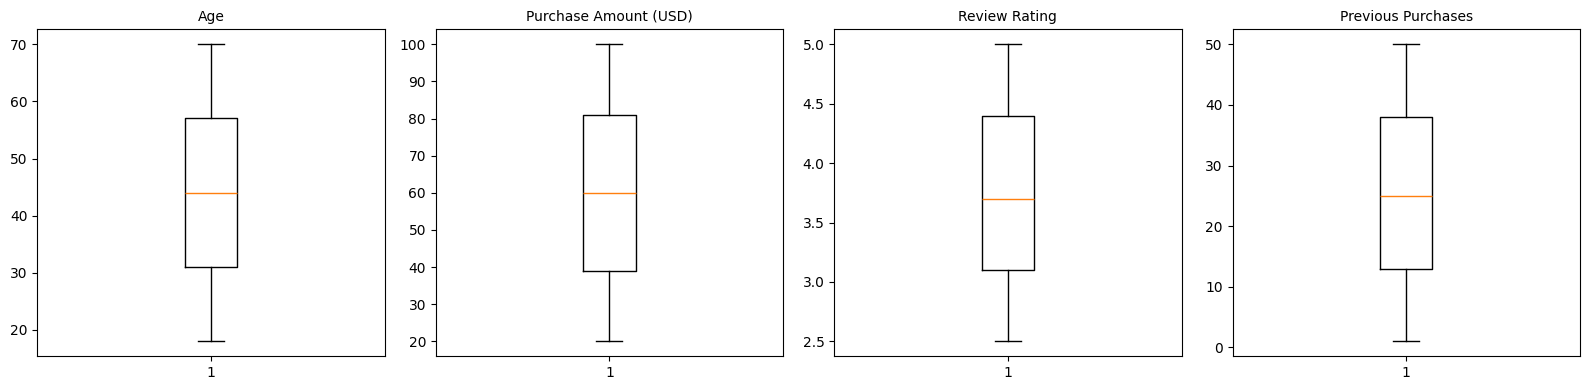

In [8]:
numerical_cols = ['Age', 'Purchase Amount (USD)', 'Review Rating', 'Previous Purchases']

print("Outlier Detection (IQR Method):")
print()
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outlier_count = len(df[(df[col] < lower) | (df[col] > upper)])
    print(f"  {col}: Q1={Q1}, Q3={Q3}, IQR={IQR}, Bounds=[{lower:.1f}, {upper:.1f}], Outliers: {outlier_count}")

# Box plots for visual confirmation
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, col in enumerate(numerical_cols):
    axes[i].boxplot(df[col])
    axes[i].set_title(col, fontsize=10)

plt.tight_layout()
plt.savefig('phase_a_outliers.png', dpi=150, bbox_inches='tight')
plt.show()

**Observation:**
* No outliers detected across all numerical columns using the IQR method
* This is might be due to the dataset being curated/synthetic as declared in Kaggle
* No outlier treatment is required in Step 3, but we will document this finding in the preprocessing section for completeness

# **Additional Data Validation**
## Oveview of Demographic Vectors in preparation for Bias Auditing (Step 5)

In [9]:
demographic_cols = []

In [10]:
# Age
if 'Age' in df.columns:
  print(f"Age Range: {df['Age'].min()} - {df['Age'].max()} with Mean of {df['Age'].mean():.1f}")
  demographic_cols.append('Age')
# Gender
if 'Gender' in df.columns:
    print(f"Gender Values: {df['Gender'].unique().tolist()} with Distribution of {df['Gender'].value_counts().to_dict()}")
    demographic_cols.append('Gender')
# Location
if 'Location' in df.columns:
    print(f"Unique Locations: {df['Location'].nunique()}")
    demographic_cols.append('Location')


Age Range: 18 - 70 with Mean of 44.1
Gender Values: ['Male', 'Female'] with Distribution of {'Male': 2652, 'Female': 1248}
Unique Locations: 50


In [11]:
# Create age groups for downstream use
bins = [0, 25, 35, 50, 100]
labels = ['18-25', '26-35', '36-50', '50+']
df['age_group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=True)

# Check if demographic groups have enough users for reliable bias analysis
print(df['Gender'].value_counts().to_string())
print()
print(df['age_group'].value_counts().sort_index().to_string())

Gender
Male      2652
Female    1248

age_group
18-25     571
26-35     742
36-50    1111
50+      1476


In [12]:
# Product features available for Content-Based model (Model 4)
print("Product Features for Content-Based Modeling:")
product_feature_cols = ['Item Purchased', 'Category', 'Size', 'Color', 'Season']
for col_name in product_feature_cols:
  print(f"  {col_name}: {df[col_name].nunique()} unique {df[col_name].unique()[:5].tolist()}")

# Check if any column has long text to determine if we will enable TF-IDF
has_text = any(df[col].dtype == 'object' and df[col].str.len().mean() > 50 for col in df.columns)
print(f"Text descriptions available: {has_text}")

Product Features for Content-Based Modeling:
  Item Purchased: 25 unique ['Blouse', 'Sweater', 'Jeans', 'Sandals', 'Sneakers']
  Category: 4 unique ['Clothing', 'Footwear', 'Outerwear', 'Accessories']
  Size: 4 unique ['L', 'S', 'M', 'XL']
  Color: 25 unique ['Gray', 'Maroon', 'Turquoise', 'White', 'Charcoal']
  Season: 4 unique ['Winter', 'Spring', 'Summer', 'Fall']
Text descriptions available: False


**Observation:**
* No text descriptions found in the dataset
* Content-Based model (Model 4) will use multi-hot encoding on Category, Size, Color, and Season with cosine similarity
* Product features available: Item Purchased (25 unique), Category (4), Size (4), Color (25), Season (4) which has sufficient richness for content-based modeling

In [13]:
# Review Rating validation to determine if RMSE is applicable
if 'Review Rating' in df.columns:
    print("Explicit ratings found under column: Review Rating")
    print(f"  Range: {df['Review Rating'].min()} to {df['Review Rating'].max()}")
    print(f"  Mean: {df['Review Rating'].mean():.2f} with Std: {df['Review Rating'].std():.2f}")
    print(df['Review Rating'].describe())
    rmse_included = True
else:
    rmse_included = False

Explicit ratings found under column: Review Rating
  Range: 2.5 to 5.0
  Mean: 3.75 with Std: 0.72
count    3900.000000
mean        3.749949
std         0.716223
min         2.500000
25%         3.100000
50%         3.700000
75%         4.400000
max         5.000000
Name: Review Rating, dtype: float64


**Decision:**
* RMSE is included as a supporting metric since the dataset contains explicit star ratings (Review Rating: 2.5–5.0).
* This is consistent with our Technical Success Metrics definition in Step 1.

In [14]:
# Missing values
print("Missing Values:")
missing = df.isnull().sum()
if missing.sum() == 0:
    print("  No Missing Values")
else:
    print(missing[missing > 0])

# Duplicates
print(f"\nDuplicate rows: {df.duplicated().sum()}")

# Customer ID and interaction sparsity
unique_customers = df['Customer ID'].nunique()
unique_items = df['Item Purchased'].nunique()
total_possible = unique_customers * unique_items
sparsity = 1 - (len(df) / total_possible)

print(f"\nInteraction Matrix:")
print(f"  Unique customers: {unique_customers}")
print(f"  Unique items: {unique_items}")
print(f"  Transactions: {len(df)}")
print(f"  Possible interactions: {total_possible:,}")
print(f"  Sparsity: {sparsity*100:.1f}%")
print(f"  Avg transactions per customer: {len(df) / unique_customers:.1f}")

Missing Values:
  No Missing Values

Duplicate rows: 0

Interaction Matrix:
  Unique customers: 3900
  Unique items: 25
  Transactions: 3900
  Possible interactions: 97,500
  Sparsity: 96.0%
  Avg transactions per customer: 1.0


**Observations:**
* The dataset is clean with zero missing values and zero duplicate rows
* Each customer has exactly 1 transaction, resulting in a 96% sparse interaction matrix
  * This means, collaborative filtering (Model 3) will face a challenge
  * The reason to include K-Means (Model 2) and XGBoost (Model 5) in our model lineup, so we can handle this scenario

## Train/Test Split Strategy

* The dataset has no date or timestamp column, so a temporal split is not possible
* Instead, we will apply a demographic-stratified random split (80/20) stratified on age_group and Gender
* This preserves demographic distribution across both sets and ensures Step 5 bias auditing can be performed reliably on the test set
* This will be documented in the Step 5 Limitations section.

In [15]:
# Stratified 80/20 split on age_group and gender
df['_strat_key'] = df['Gender'] + '_' + df['age_group'].astype(str)

df_train, df_test = train_test_split(
    df, test_size=0.2, random_state=42,
    stratify=df['_strat_key']
)

print(f"Training set: {len(df_train)} rows ({len(df_train)/len(df)*100:.0f}%)")
print(f"Test set: {len(df_test)} rows ({len(df_test)/len(df)*100:.0f}%)")

# Verify stratification
print("\nStratification Verification:")
for group in sorted(df['_strat_key'].unique()):
    train_pct = (df_train['_strat_key'] == group).mean() * 100
    test_pct = (df_test['_strat_key'] == group).mean() * 100
    print(f"  {group}: train {train_pct:.1f}%, test {test_pct:.1f}%")

# Clean up helper column
df_train = df_train.drop(columns=['_strat_key'])
df_test = df_test.drop(columns=['_strat_key'])
df = df.drop(columns=['_strat_key'])

Training set: 3120 rows (80%)
Test set: 780 rows (20%)

Stratification Verification:
  Female_18-25: train 4.4%, test 4.5%
  Female_26-35: train 6.2%, test 6.2%
  Female_36-50: train 9.6%, test 9.6%
  Female_50+: train 11.7%, test 11.8%
  Male_18-25: train 10.2%, test 10.1%
  Male_26-35: train 12.8%, test 12.8%
  Male_36-50: train 18.9%, test 18.8%
  Male_50+: train 26.1%, test 26.2%


**Result:**
* Demographic distribution is preserved across train and test sets
* All age_group and gender combinations show less than 1% variance between splits.

# **Data Dictionary**
## Provide a data dictionary (variables, types, units, allowed values).


| Column | Type | Unique | Missing | Description |
|--------|------|--------|---------|-------------|
| Customer ID | int64 | 3,900 | 0 | Unique identifier for each customer |
| Age | int64 | 53 | 0 | Customer age in years (demographic vector for Step 5 bias audit) |
| Gender | object | 2 | 0 | Customer gender which is Male, Female (demographic vector for Step 5 bias audit) |
| Item Purchased | object | 25 | 0 | Specific product name purchased by the customer |
| Category | object | 4 | 0 | Product category: Clothing, Accessories, Footwear, Outerwear |
| Purchase Amount (USD) | int64 | 81 | 0 | Transaction value in US dollars |
| Location | object | 50 | 0 | US state of the customer (demographic vector for Step 5 bias audit) |
| Size | object | 4 | 0 | Product size: S, M, L, XL |
| Color | object | 25 | 0 | Product color variant |
| Season | object | 4 | 0 | Season of purchase: Winter, Spring, Summer, Fall |
| Review Rating | float64 | 26 | 0 | Customer satisfaction score, 2.5 to 5.0 scale (explicit feedback) |
| Subscription Status | object | 2 | 0 | Whether the customer has an active subscription: Yes or No |
| Shipping Type | object | 6 | 0 | Shipping method selected |
| Discount Applied | object | 2 | 0 | Whether a discount was applied: Yes or No |
| Promo Code Used | object | 2 | 0 | Whether a promotional code was used: Yes or No |
| Previous Purchases | int64 | 50 | 0 | Count of prior purchases by this customer, range 1 to 50 |
| Payment Method | object | 6 | 0 | Payment method used for the transaction |
| Frequency of Purchases | object | 7 | 0 | Self-reported purchase frequency: Weekly, Bi-Weekly, etc. |
| age_group | category | 4 | 0 | Derived: Age segmented into 18-25, 26-35, 36-50, 50+ for bias auditing |

### Key Distributions

These visualizations serve a dual purpose:
* Provide an initial understanding of the dataset's structure and spread for Step 2
* Designed to be reusable in Step 6 presentations (technical and business decks) to avoid recreating charts later, adhering to the "Reusability" and DRY (Don't Repeat Yourself) principles across this project from standard Software Engineering and MLOps approach so our visuals are produced once and referenced across deliverables.

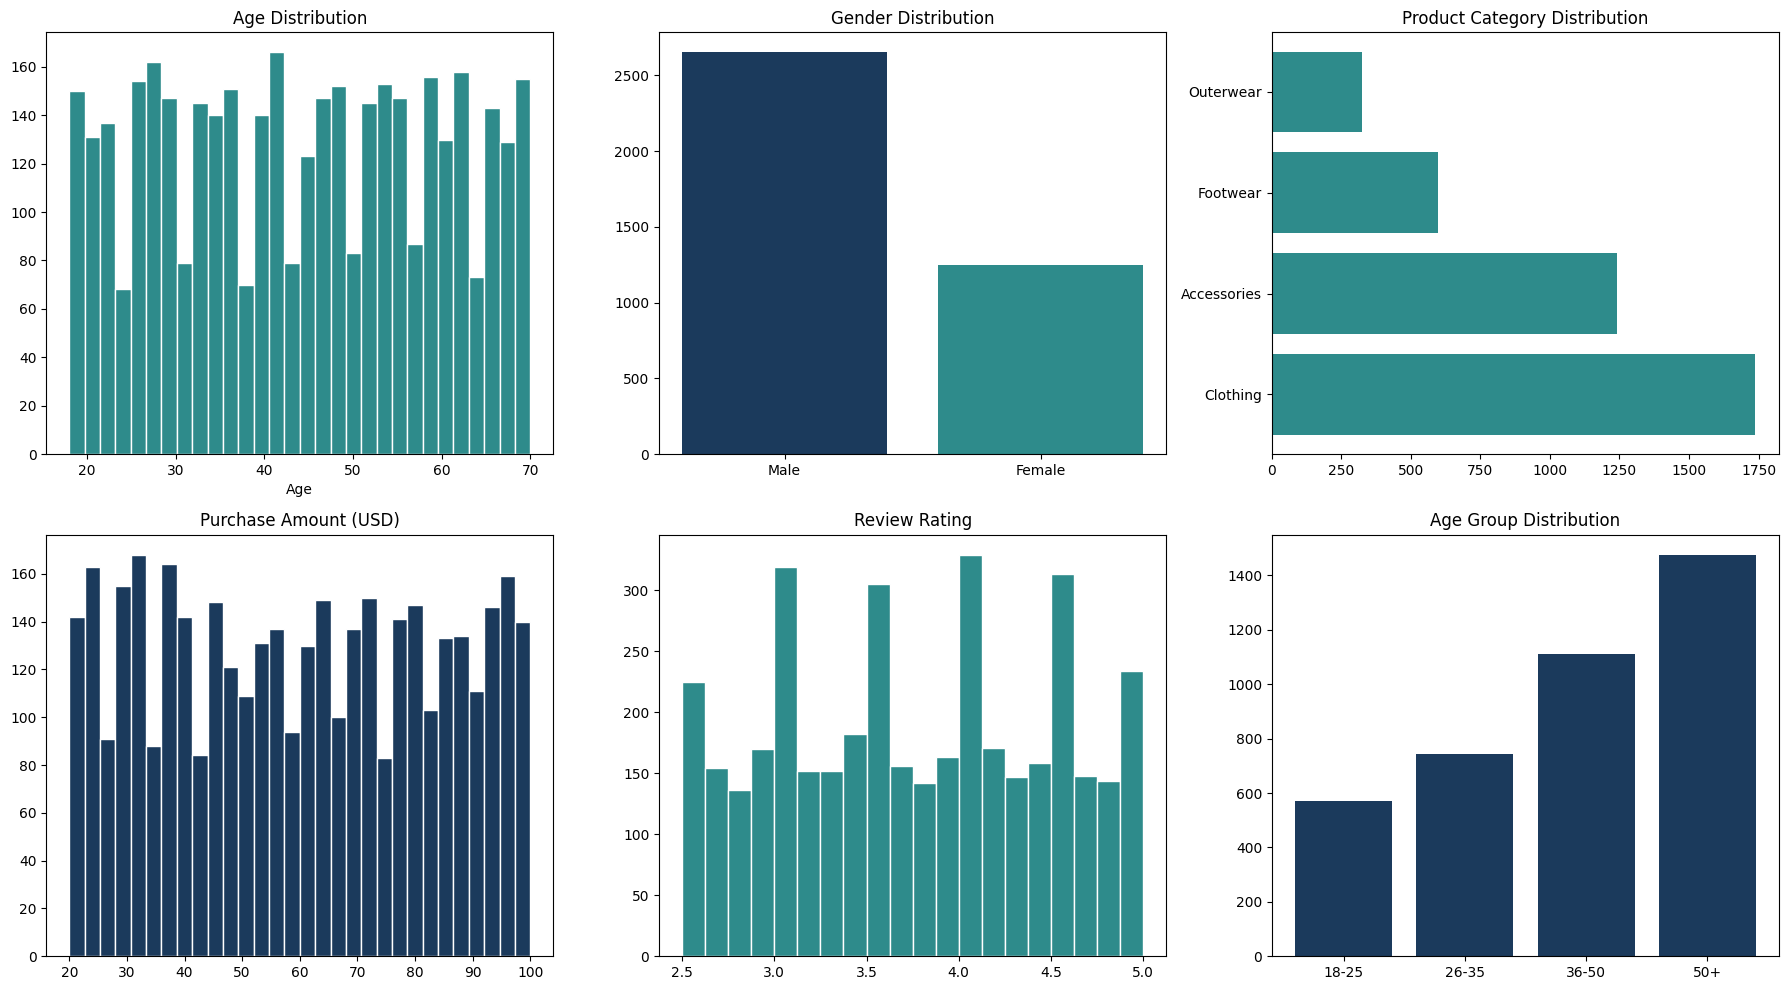

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
COLOR_PRIMARY = '#1B3A5C'
COLOR_SECONDARY = '#2E8B8B'
COLOR_ACCENT = '#D4820C'

# Age
axes[0, 0].hist(df['Age'], bins=30, color= COLOR_SECONDARY, edgecolor='white')
axes[0, 0].set_title('Age Distribution')
axes[0, 0].set_xlabel('Age')

# Gender
gender_counts = df['Gender'].value_counts()
axes[0, 1].bar(gender_counts.index, gender_counts.values, color=[COLOR_PRIMARY, COLOR_SECONDARY])
axes[0, 1].set_title('Gender Distribution')

# Category
cat_counts = df['Category'].value_counts()
axes[0, 2].barh(cat_counts.index, cat_counts.values, color=COLOR_SECONDARY)
axes[0, 2].set_title('Product Category Distribution')

# Purchase Amount
axes[1, 0].hist(df['Purchase Amount (USD)'], bins=30, color=COLOR_PRIMARY, edgecolor='white')
axes[1, 0].set_title('Purchase Amount (USD)')

# Review Rating
axes[1, 1].hist(df['Review Rating'], bins=20, color=COLOR_SECONDARY, edgecolor='white')
axes[1, 1].set_title('Review Rating')

# Age Groups
age_counts = df['age_group'].value_counts().sort_index()
axes[1, 2].bar(age_counts.index.astype(str), age_counts.values, color=COLOR_PRIMARY)
axes[1, 2].set_title('Age Group Distribution')

plt.tight_layout()
plt.savefig('phase_a_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
df_train.to_csv('train_set.csv', index=False)
df_test.to_csv('test_set.csv', index=False)
df.to_csv('full_dataset_with_age_group.csv', index=False)

#**Phase A Summary: Foundation & Provisioning Delivered**

**Step 1: Problem Understanding & Framing:**
* **Business problem framed:** Increase AOV and retention through personalized product recommendations
* **Data science problem framed:** Predict and rank Top-K items users are likely to purchase or engage using a hybrid recommendation approach
* **Task type:** Recommendation System (Hybrid)
* **Technical metrics defined:**
  * Precision@K, Recall@K, NDCG@K (K=5, K=10) with NDCG@10 as primary tollgate metric
  * RMSE included as supporting metric (explicit ratings were confirmed)
  * Silhouette Score for K-Means cluster validation
* **Business KPIs:** Projected AOV uplift (%), CTR on recommendations

**Step 2 Data Collection & Understanding:**
* **Dataset:** Customer Shopping Trends Dataset (Kaggle, 3,900 rows × 18 columns)
* **Feature types:** 4 numerical (int64), 1 continuous (float64), 13 categorical (object), and 1 derived column (age_group)
* **Data quality:** Zero missing values, zero duplicates, zero outliers via IQR
* **Additional Data Validation Performed in preparation with succeeding steps:**
  * **Demographics validated:** Age (4 groups, all are more than 500 in count), Gender (2 groups, both are over 1,200), Location (50 US states)
  * **Product features:** 4 categorical features (Category, Size, Color, Season) will be used for multi-hot encoding in the content-based model, with Item Purchased serving as the item identifier
  * **Interaction type:** Explicit ratings (Review Rating 2.5 to 5.0)
  * Sparsity: 96% (1 transaction per customer), confirms K-Means and XGBoost architectural decision
* **Data dictionary** completed with types, unique values, and business meaning per column

**Solution Decisions Confirmed:**
* RMSE is included
* Content-based strategy: Multi-hot encoding on Category, Size, Color, Season
* Train/test split: 80/20 demographic-stratified random split because no temporal column is available. To be disclosed in Step 5 Limitations
* Primary tollgate metric: NDCG@10

**Next Phase: Phase B**
* **Step 3**: Data Preprocessing, Applied EDA & Feature Engineering

# **Step 3: Data Preprocessing, Applied EDA & Feature Engineering**

* Clean data: Handle nulls, duplicates and outliers
* Engineer features: Scaling, encoding, binning and domain-derived features
* Applied EDA: Distributions, relationships, clustering tendency (if unsupervised)
* Feature importance & explainability: SHAP, LIME, or model-based importances
* Feature selection: At least one approach (filter, wrapper, or embedded)
* Dimensionality reduction: PCA (and t-SNE/UMAP for visualisation if needed)

**Deliverable:**
"EDA + Feature Engineering Report" with reproducible code & justifications


# **Data Preprocessing**
## Clean data: Handle nulls, duplicates and outliers
* Phase A confirmed zero missing values, zero duplicate rows, and zero outliers (via IQR method) across all numerical columns
* No imputation or removal is required as documented in the Phase A cells above under Dataset Overview

## Engineer features: Scaling, encoding, binning and domain-derived features

**Binning:**
* Age was binned into four demographic groups (18-25, 26-35, 36-50, 50+) during Phase A (which can both be observed under "Additional Data Validation") for use in bias auditing and as a modeling feature
* This can also be additionally observed in the visuals created "Key Distributions"

In [18]:
df_encoded = df.copy()

# Binary encoding (0/1)
df_encoded['Gender'] = df_encoded['Gender'].map({'Male': 1, 'Female': 0})
df_encoded['Subscription Status'] = df_encoded['Subscription Status'].map({'Yes': 1, 'No': 0})
df_encoded['Discount Applied'] = df_encoded['Discount Applied'].map({'Yes': 1, 'No': 0})
df_encoded['Promo Code Used'] = df_encoded['Promo Code Used'].map({'Yes': 1, 'No': 0})

# Ordinal encoding (natural order)
size_order = {'S': 0, 'M': 1, 'L': 2, 'XL': 3}
df_encoded['Size'] = df_encoded['Size'].map(size_order)

freq_order = {
    'Annually': 0, 'Quarterly': 1, 'Every 3 Months': 2,
    'Monthly': 3, 'Bi-Weekly': 4, 'Fortnightly': 5, 'Weekly': 6
}
df_encoded['Frequency of Purchases'] = df_encoded['Frequency of Purchases'].map(freq_order)

# One-Hot encoding (no natural order)
nominal_cols = ['Category', 'Color', 'Season', 'Payment Method', 'Shipping Type']
df_encoded = pd.get_dummies(df_encoded, columns=nominal_cols, drop_first=False)

print(f"Shape after encoding: {df_encoded.shape}")
print(f"Columns: {df_encoded.shape[1]}")
df_encoded

Shape after encoding: (3900, 59)
Columns: 59


,Customer ID,Age,Gender,Item Purchased,Purchase Amount (USD),Location,Size,Review Rating,Subscription Status,Discount Applied,Promo Code Used,Previous Purchases,Frequency of Purchases,age_group,Category_Accessories,Category_Clothing,Category_Footwear,Category_Outerwear,Color_Beige,Color_Black,Color_Blue,Color_Brown,Color_Charcoal,Color_Cyan,Color_Gold,Color_Gray,Color_Green,Color_Indigo,Color_Lavender,Color_Magenta,Color_Maroon,Color_Olive,Color_Orange,Color_Peach,Color_Pink,Color_Purple,Color_Red,Color_Silver,Color_Teal,Color_Turquoise,Color_Violet,Color_White,Color_Yellow,Season_Fall,Season_Spring,Season_Summer,Season_Winter,Payment Method_Bank Transfer,Payment Method_Cash,Payment Method_Credit Card,Payment Method_Debit Card,Payment Method_PayPal,Payment Method_Venmo,Shipping Type_2-Day Shipping,Shipping Type_Express,Shipping Type_Free Shipping,Shipping Type_Next Day Air,Shipping Type_Standard,Shipping Type_Store Pickup
0,1,55,1,Blouse,53,Kentucky,2,3.1,1,1,1,14,5,50+,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,True,False,False,False,False
1,2,19,1,Sweater,64,Maine,2,3.1,1,1,1,2,5,18-25,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,True,False,False,False,False
2,3,50,1,Jeans,73,Massachusetts,0,3.1,1,1,1,23,6,36-50,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,True,False,False,False
3,4,21,1,Sandals,90,Rhode Island,1,3.5,1,1,1,49,6,18-25,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True,False,False
4,5,45,1,Blouse,49,Oregon,1,2.7,1,1,1,31,0,36-50,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3895,3896,40,0,Hoodie,28,Virginia,2,4.2,0,0,0,32,6,36-50,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,True,True,False,False,False,False,False
3896,3897,52,0,Backpack,49,Iowa,2,4.5,0,0,0,41,4,50+,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,True
3897,3898,46,0,Belt,33,New Jersey,2,2.9,0,0,0,24,1,36-50,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,True,False
3898,3899,44,0,Shoes,77,Minnesota,0,3.8,0,0,0,24,6,36-50,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,Fals

**Encoding**
* Our model lineup will include distance-based (K-Means), tree-based (XGBoost), collaborative filtering, and content-based approaches
* Each consumes different input formats, so we prepared a unified encoded dataset that any downstream model can select from:

  * **Binary columns** (Gender, Subscription Status, Discount Applied, Promo Code Used): Mapped to 0 and 1
  * **Ordinal columns** (Size, Frequency of Purchases): Encoded with natural ordering preserved (e.g., S=0, M=1, L=2, XL=3)
  * **Nominal columns** (Category, Color, Season, Payment Method, Shipping Type): One-Hot Encoded since these have no natural order
  * **Item Purchased** was Left as-is since this is the item identifier used in the interaction matrix; and not a model feature
- **Customer ID** was also be left as-is since it will be our row identifier

In [19]:
# Scaling numerical features
# XGBoost tolerates unscaled but was included for consistency as it is required for K-Means since it is distance-based
numerical_cols = ['Age', 'Purchase Amount (USD)', 'Review Rating', 'Previous Purchases']

scaler = StandardScaler()
df_encoded[numerical_cols] = scaler.fit_transform(df_encoded[numerical_cols])

print(df_encoded[numerical_cols].describe().round(2))
df_encoded


           Age  Purchase Amount (USD)  Review Rating  Previous Purchases
count  3900.00                3900.00        3900.00             3900.00
mean     -0.00                  -0.00           0.00                0.00
std       1.00                   1.00           1.00                1.00
min      -1.71                  -1.68          -1.75               -1.69
25%      -0.86                  -0.88          -0.91               -0.86
50%      -0.00                   0.01          -0.07               -0.02
75%       0.85                   0.90           0.91                0.88
max       1.71                   1.70           1.75                1.71


,Customer ID,Age,Gender,Item Purchased,Purchase Amount (USD),Location,Size,Review Rating,Subscription Status,Discount Applied,Promo Code Used,Previous Purchases,Frequency of Purchases,age_group,Category_Accessories,Category_Clothing,Category_Footwear,Category_Outerwear,Color_Beige,Color_Black,Color_Blue,Color_Brown,Color_Charcoal,Color_Cyan,Color_Gold,Color_Gray,Color_Green,Color_Indigo,Color_Lavender,Color_Magenta,Color_Maroon,Color_Olive,Color_Orange,Color_Peach,Color_Pink,Color_Purple,Color_Red,Color_Silver,Color_Teal,Color_Turquoise,Color_Violet,Color_White,Color_Yellow,Season_Fall,Season_Spring,Season_Summer,Season_Winter,Payment Method_Bank Transfer,Payment Method_Cash,Payment Method_Credit Card,Payment Method_Debit Card,Payment Method_PayPal,Payment Method_Venmo,Shipping Type_2-Day Shipping,Shipping Type_Express,Shipping Type_Free Shipping,Shipping Type_Next Day Air,Shipping Type_Standard,Shipping Type_Store Pickup
0,1,0.718913,1,Blouse,-0.285629,Kentucky,2,-0.907584,1,1,1,-0.785831,5,50+,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,True,False,False,False,False
1,2,-1.648629,1,Sweater,0.178852,Maine,2,-0.907584,1,1,1,-1.616552,5,18-25,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,True,False,False,False,False
2,3,0.390088,1,Jeans,0.558882,Massachusetts,0,-0.907584,1,1,1,-0.162789,6,36-50,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,True,False,False,False
3,4,-1.517099,1,Sandals,1.276716,Rhode Island,1,-0.349027,1,1,1,1.637107,6,18-25,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True,False,False
4,5,0.061263,1,Blouse,-0.454531,Oregon,1,-1.466141,1,1,1,0.391025,0,36-50,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3895,3896,-0.267563,0,Hoodie,-1.341267,Virginia,2,0.628448,0,0,0,0.460252,6,36-50,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,True,True,False,False,False,False,False
3896,3897,0.521618,0,Backpack,-0.454531,Iowa,2,1.047366,0,0,0,1.083293,4,50+,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,True
3897,3898,0.127028,0,Belt,-1.130139,New Jersey,2,-1.186862,0,0,0,-0.093563,1,36-50,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,True,False
3898,3899,-0.004502,0,Shoes,0.727784,Minnesota,0,0.069891,0,0,0,-0.093563,6,3

**Observation:**

* After encoding and scaling, the dataset expanded from 18 to 59 columns due to One-Hot encoding of nominal categories (Category, Color, Season, Payment Method, Shipping Type)
* Numerical features are now standardized with mean = 0 and std = 1, which is required for distance-based algorithms like K-Means
* Tree-based models such as XGBoost are not really affected by scaling but a consistent representation simplifies our pipeline

## Applied EDA: Distributions, relationships, clustering tendency (if unsupervised)

* Basic Distribustion can be observed under "Key Distributions" section of the code, showing distributions of age, gender, category, purchase amount, and review rating
* So in this section, we will focus more on relationship and patterns that will feed into our Business Insight, recommendation logic, and bias auditing

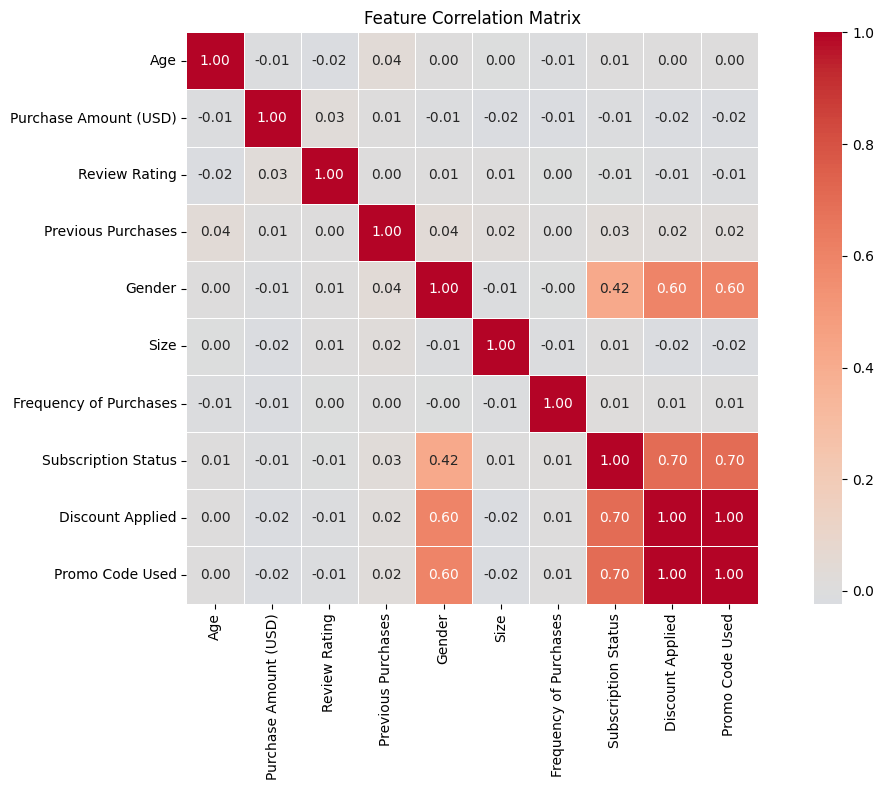

In [20]:
# Correlation heatmap on numerical features
numerical_features = ['Age', 'Purchase Amount (USD)', 'Review Rating', 'Previous Purchases',
                      'Gender', 'Size', 'Frequency of Purchases', 'Subscription Status',
                      'Discount Applied', 'Promo Code Used']

corr_matrix = df_encoded[numerical_features].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('phase_b_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

**Observations from Correlation Analysis:**
* **Discount Applied and Promo Code Used have a perfect correlation of 1.00**: these means that the two columns contain identical information
  * We will drop "Promo Code Used" before modeling since it is identical to "Discount Applied" to avoid redundancy
* **Subscription Status correlates with Discount Applied (0.70) or Promo Code Used (0.70)**: this suggest subscribers are more likely to use discounts and promos
* **Gender shows moderate correlation with Subscription Status (0.42) and Discount Applied (0.60)**: this imply that both these features are not independent of gender
  * The nature of this relationship will be explored further during Step 5 bias auditing
* **Age, Purchase Amount, Review Rating, and Previous Purchases show near-zero correlations with each other**: this means that these features are largely independent from each other
  * This is good for our modeling since they each carry unique information without multicollinearity


In [33]:
df_encoded = df_encoded.drop(columns=['Promo Code Used'])
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 58 columns):
 #   Column                        Non-Null Count  Dtype   
---  ------                        --------------  -----   
 0   Customer ID                   3900 non-null   int64   
 1   Age                           3900 non-null   float64 
 2   Gender                        3900 non-null   int64   
 3   Item Purchased                3900 non-null   object  
 4   Purchase Amount (USD)         3900 non-null   float64 
 5   Location                      3900 non-null   object  
 6   Size                          3900 non-null   int64   
 7   Review Rating                 3900 non-null   float64 
 8   Subscription Status           3900 non-null   int64   
 9   Discount Applied              3900 non-null   int64   
 10  Previous Purchases            3900 non-null   float64 
 11  Frequency of Purchases        3900 non-null   int64   
 12  age_group                     3900 non-null   ca

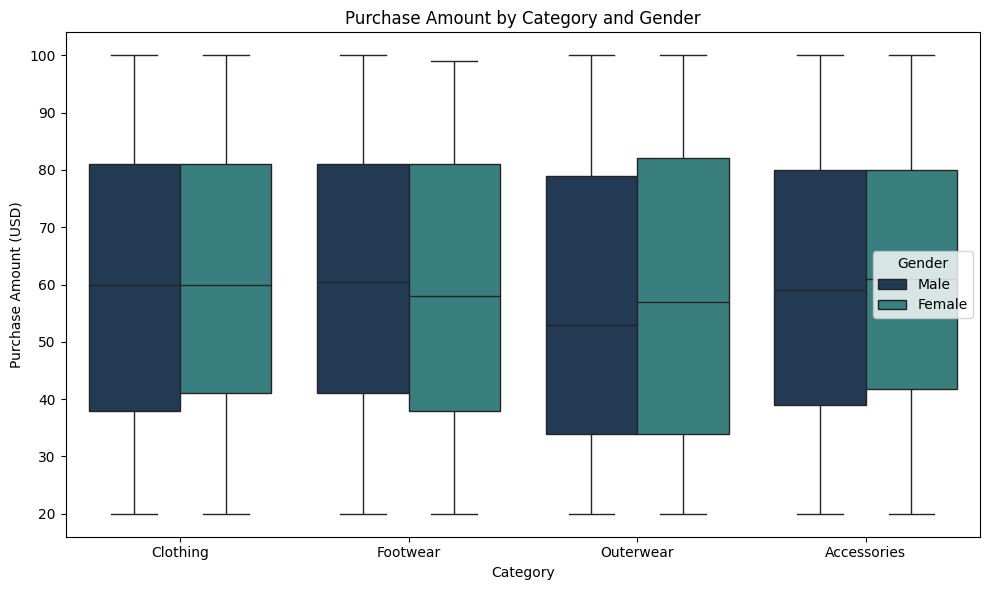

In [34]:
# Purchase amount by category and gender (used original df for more readable labels)
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=df, x='Category', y='Purchase Amount (USD)', hue='Gender',
            palette=[COLOR_PRIMARY, COLOR_SECONDARY])
ax.set_title('Purchase Amount by Category and Gender')
plt.tight_layout()
plt.savefig('phase_b_category_gender_spending.png', dpi=150, bbox_inches='tight')
plt.show()

**Observation:**
* Purchase amounts are distributed similarly across all four categories and both genders
* Medians hover around $55 to $60 with comparable spread
* This suggests that purchase amount alone is not a strong differentiator for recommending products
* The recommendation engine should rely more on other features like category preferences and item-level behavior than on spending patterns

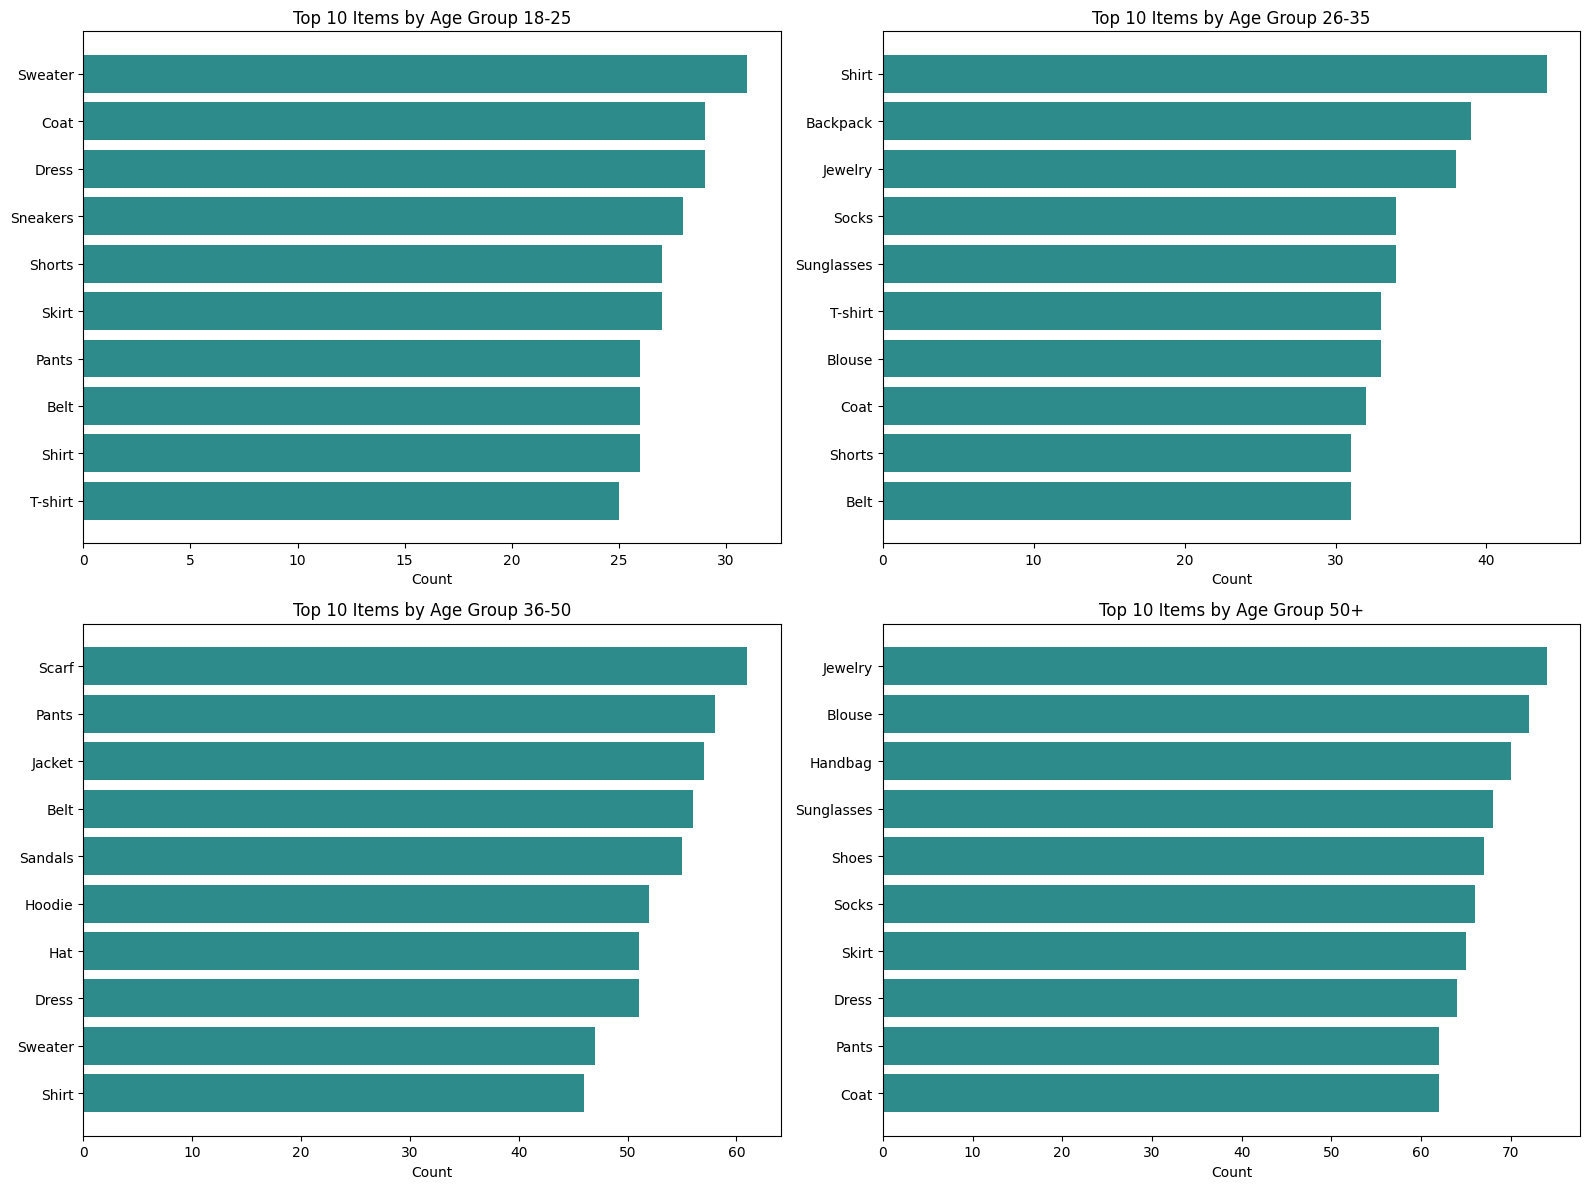

In [35]:
# Top 10 most purchased items per age group
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
age_groups = ['18-25', '26-35', '36-50', '50+']

for i, ag in enumerate(age_groups):
    ax = axes[i // 2][i % 2]
    subset = df[df['age_group'] == ag]
    item_counts = subset['Item Purchased'].value_counts().head(10)
    ax.barh(item_counts.index, item_counts.values, color=COLOR_SECONDARY)
    ax.set_title(f'Top 10 Items by Age Group {ag}')
    ax.set_xlabel('Count')
    ax.invert_yaxis()

plt.tight_layout()
plt.savefig('phase_b_item_popularity_by_age.png', dpi=150, bbox_inches='tight')
plt.show()

**Observation:**

Item preferences show some variation across age groups, though the counts are relatively evenly distributed within each group (might be due to the data being synthetic)
* **18-25:** Sweater, Coat, and Dress lead which skews toward smart casual and seasonal clothing
* **26-35:** Shirt, Backpack, and Jewelry top the list which is a mix of professional and accessory items
* **36-50:** Scarf, Pants, and Jacket dominate which are more practical, work-appropriate items
* **50+:** Jewelry, Blouse, and Handbag lead which are accessories and classic clothing items
  * The 50+ group shows the highest item counts overall, which is expected since it has the largest population (1,476 users)
* These age-specific preferences support using age group as a feature in the recommendation model, particularly for the K-Means cluster-based approach where cluster-level item popularity drives recommendations

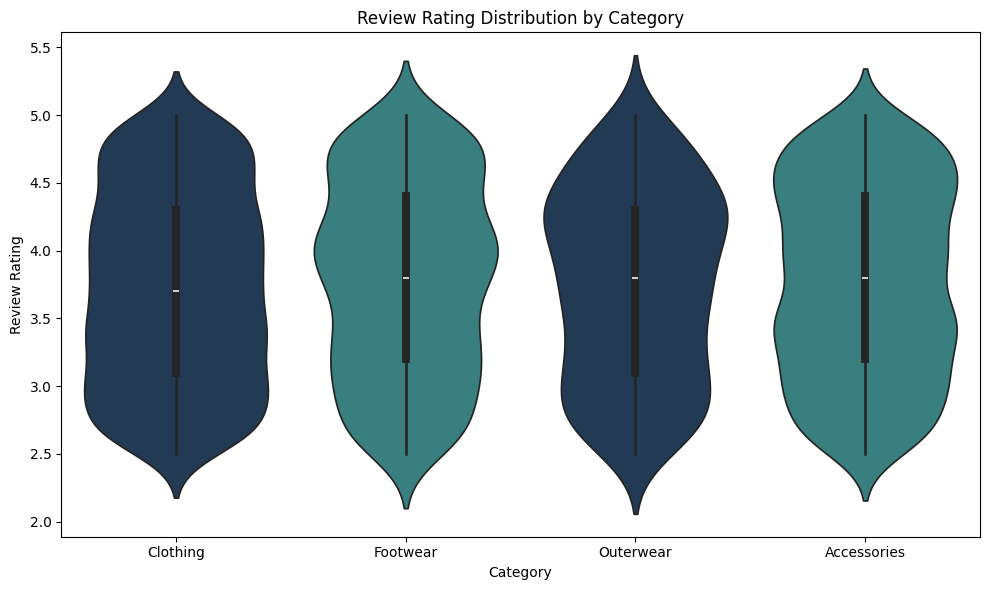

Category
Accessories    3.8
Clothing       3.7
Footwear       3.8
Outerwear      3.8
Name: Review Rating, dtype: float64


In [37]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.violinplot(data=df, x='Category', y='Review Rating',
               palette=[COLOR_PRIMARY, COLOR_SECONDARY, COLOR_PRIMARY, COLOR_SECONDARY])
ax.set_title('Review Rating Distribution by Category')
plt.tight_layout()
plt.savefig('phase_b_rating_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

print(df.groupby('Category')['Review Rating'].median())

**Observation:**

Review rating distributions are nearly identical across all four categories, with medians around 3.7 to 3.8 and similar spread
* All categories show a roughly uniform distribution between 2.5 and 5.0, with no category standing out as significantly better or worse rated
* This means review rating alone will not be a useful feature for differentiating between categories in the recommendation model since it carries customer satisfaction signal but not category preference signal
* This further support our correlation heatmap where Review Rating showed near-zero correlation with other features

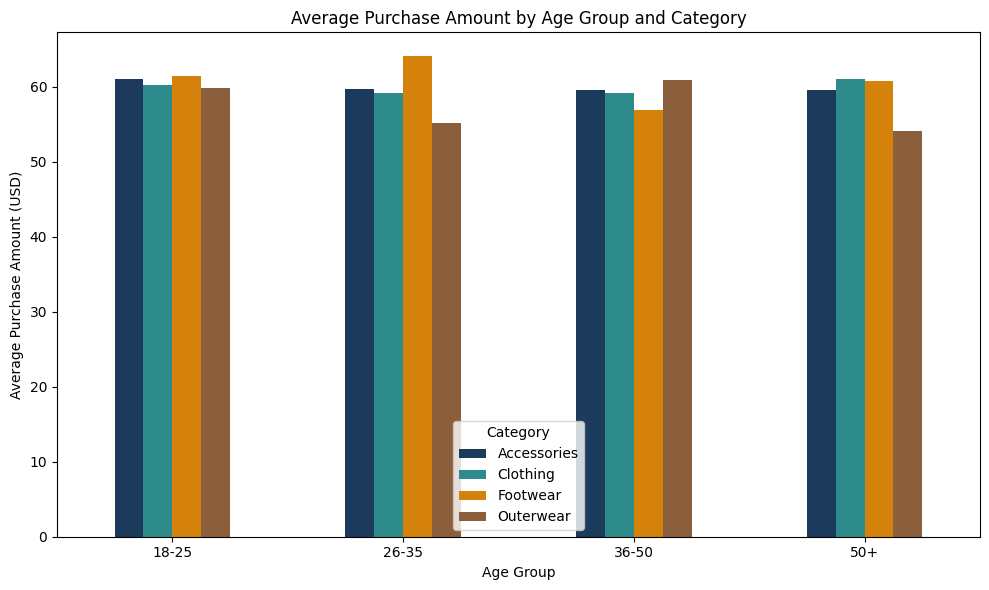


Average Purchase Amount by Age Group vs Category:
Category   Accessories  Clothing  Footwear  Outerwear
age_group                                            
18-25            61.11     60.30     61.38      59.78
26-35            59.67     59.18     64.06      55.22
36-50            59.62     59.13     56.86      60.92
50+              59.63     61.01     60.74      54.08


In [39]:
# Average purchase amount by age group and category
spending = df.groupby(['age_group', 'Category'])['Purchase Amount (USD)'].mean().unstack()

fig, ax = plt.subplots(figsize=(10, 6))
spending.plot(kind='bar', ax=ax, color=[COLOR_PRIMARY, COLOR_SECONDARY, '#D4820C', '#8B5E3C'])
ax.set_title('Average Purchase Amount by Age Group and Category')
ax.set_xlabel('Age Group')
ax.set_ylabel('Average Purchase Amount (USD)')
ax.legend(title='Category')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('phase_b_spending_age_category.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nAverage Purchase Amount by Age Group vs Category:")
print(spending.round(2))

**Observation:**
* Average spending is consistent across all age group and category combinations (within the $55 to $64 range)
* Slight variations observed:
  * 26-35 group spends slightly higher on Footwear ($64.06) while less on Outerwear ($55.22)
  * Similar Outerwear spending pattern ($54.08) observed with 50+ group
* Overall, spending amount does not vary meaningfully by age group or category which reinforces earlier finding from chart 2 that purchase amount is not a strong differentiator
* The recommendation engine's value will come from predicting *which* items a user wants, not *how much* they spend
  * Item preference patterns as observed in chart 3 (Top 10 most purchased items per age group graph) are more actionable than spending patterns

### Domain-Driven Feature Engineering

* Originally anticipated features like purchase_frequency, days_since_last_purchase, average_order_value, category_diversity_score, and brand_loyalty_index

  * However, the dataset chosen contains 1 transaction per customer only with no date column and no brand column
  * This limited some of the planned features but opened an opportunity to engineer different ones that leverage the data we have

* The main goal is to create features that helps the recommendation models understand user preferences and behavior beyond the raw columns
* Applied EDA was performed before feature engineering so the patterns discovered in the data could directly inform which features to create

In [ ]:
# Domain-driven feature engineering
# Worked on the original df (not df_encoded) since we need readable labels for feature logic
# New features will be encoded and added to df_encoded

# Spending Tier: Bin customers into spending segments
# Business logic: high spenders may prefer premium items
df['spending_tier'] = pd.qcut(df['Purchase Amount (USD)'], q=3, labels=['low', 'mid', 'high'])
print("1. spending_tier created:")
print(df['spending_tier'].value_counts().sort_index())

# Engagement Score: Combines previous purchases with subscription and discount usage
# Business logic: higher engagement = more data for the model to learn from
df['engagement_score'] = (
    df['Previous Purchases'] +
    df['Subscription Status'].map({'Yes': 10, 'No': 0}) +
    df['Discount Applied'].map({'Yes': 5, 'No': 0})
)
print("\n2. engagement_score created:")
print(df['engagement_score'].describe().round(2))

# Price Sensitivity: Whether the customer used discount AND promo code
# Business logic: price-sensitive customers may respond to different recommendations
df['price_sensitive'] = ((df['Discount Applied'] == 'Yes') & (df['Promo Code Used'] == 'Yes')).astype(int)
print("\n3. price_sensitive created:")
print(df['price_sensitive'].value_counts())

# Season-Category Preference: Concatenation to capture seasonal shopping patterns
# Business logic: some customers buy outerwear in winter, accessories in summer
df['season_category'] = df['Season'] + '_' + df['Category']
print("\n4. season_category created:")
print(df['season_category'].value_counts().head(8))

# Purchase Recency Proxy: Using Previous Purchases as a proxy for customer maturity since we don't have a date column
# Business logic: customers with more history have more established preferences
df['customer_maturity'] = pd.cut(df['Previous Purchases'], bins=[0, 10, 25, 50],
                                  labels=['new', 'regular', 'loyal'])
print("\n5. customer_maturity created:")
print(df['customer_maturity'].value_counts().sort_index())

print(f"\nTotal features after engineering: {df.shape[1]} columns")